In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

In [2]:
df = pd.read_csv('mined_datasets/minned_work_permit_decisions_by_type.csv')
df_after_2014 = df[df.year >= 2010].copy()
df_rejection = df_after_2014[df_after_2014.permit_type == 'first-time']

In [3]:
df_rejection

,year,permit_type,number_applications_received,number_decisions_made,number_granted_applications,number_rejected_applications,approval_rate,rejection_rate,source_page,notes
18,2010,first-time,26346.0,23357.0,20788.0,2569.0,0.89,0.11,arsredovisning_2010.pdf#51,granted = round(decisions * bifallsandel) = ro...
20,2011,first-time,NaN,NaN,NaN,NaN,NaN,NaN,arsredovisning_2011.pdf#51,own report gives only Arbetsmarknadsärenden to...
22,2012,first-time,NaN,NaN,NaN,NaN,NaN,NaN,arsredovisning_2012.pdf#66,own report gives only Arbetsmarknadsärenden to...
24,2013,first-time,37367.0,36135.0,NaN,NaN,NaN,NaN,arsredovisning_2013.pdf#92,first-time/extension split sourced from arsred...
26,2014,first-time,32546.0,32846.0,24634.0,8212.0,0.75,0.25,arsredovisning_2014.pdf#116,granted = round(decisions * bifallsandel) = ro...
28,2015,first-time,37163.0,35297.0,26120.0,9177.0,0.74,0.26,arsredovisning_2015.pdf#69,granted = round(decisions * bifallsandel) = ro...
30,2016,first-time,32885.0,32172.0,24129.0,8043.0,0.75,0.25,arsredovisning_2016.pdf#56,granted = round(decisions * bifallsandel) = ro...
32,2017,first-time,38395.0,41588.0,31191.0,10397.0,0.75,0.25,arsredovisning_2017.pdf#69,granted = round(decisions * bifallsandel) = ro...
34,2018,first-time,49079.0,51455.0,40135.0,11320.0,0.78,0.22,arsredovisning_2018.pdf#100,granted = round(decisions * bifallsandel) = ro...
36,2019,first-time,59307.0,52547.0,42038.0,10509.0,0.80,0.20,arsredovisning_2019.pdf#92,granted = round(decisions * bifallsandel) = ro...


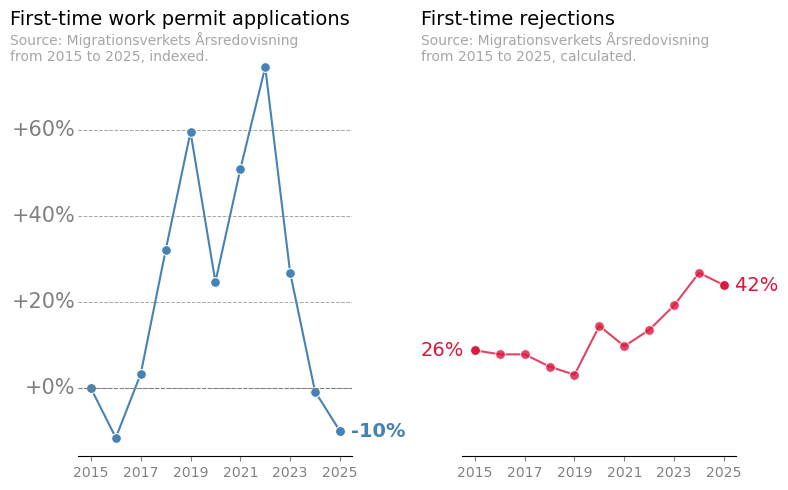

In [51]:
def build_indexed(df, baseline_year):
    out = df[df['year'] != 2026].copy()
    out = out[out['year'] >= baseline_year]
    baseline = out.loc[out['year'] == baseline_year].iloc[0]
    out['applications_received_idx'] = out['number_applications_received'] / baseline['number_applications_received'] * 100
    out['rejection_rate_pct'] = out['rejection_rate'] * 100
    out['year_label'] = out['year'].astype(str)
    return out

baseline_year = 2015
plot_df = build_indexed(df_rejection, baseline_year)
years = plot_df['year'].tolist()
tick_positions = [i for i, y in enumerate(years) if (y - baseline_year) % 2 == 0]
tick_labels = [str(years[i]) for i in tick_positions]

start_idx = 0
end_idx = len(plot_df) - 1
start_row = plot_df.iloc[start_idx]
end_row = plot_df.iloc[end_idx]
apps_change_pct = end_row['applications_received_idx'] - 100

# Applications received
fig_apps = plt.figure(figsize=(8, 5))
ax_apps = plt.subplot(121)
ax_rej = plt.subplot(122)

sns.lineplot(plot_df,
             x='year_label',
             y='applications_received_idx',
             ax=ax_apps,
             color='steelblue',
             marker='o',
             markersize=7,
             sort=False)
ax_apps.plot([start_idx, end_idx],
             [start_row['applications_received_idx'], end_row['applications_received_idx']],
             'o', color='steelblue', markersize=5)
ax_apps.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax_apps.annotate(f'{apps_change_pct:+.0f}%',
                 xy=(end_idx, end_row['applications_received_idx']),
                 xytext=(8, 0), textcoords='offset points',
                 va='center', ha='left',
                 color='steelblue', fontweight='bold',fontsize=14)
ax_apps.set_xticks(tick_positions)
ax_apps.set_xticklabels(tick_labels)

# Reference lines every 20 index points, labelled with the % change vs baseline
# (index 100 = 0%, 120 = +20%, 140 = +40%, etc.)
y_min, y_max = ax_apps.get_ylim()
trans = blended_transform_factory(ax_apps.transAxes, ax_apps.transData)
lo = 100
hi = int(y_max // 20) * 20
for v in range(max(0, lo), hi + 1, 20):
    if not (y_min <= v <= y_max):
        continue
    ax_apps.axhline(v, color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
    ax_apps.text(-0.01, v, f'{v - 100:+d}%', transform=trans,
            ha='right', va='center', fontsize=15, color='gray')


for spine in ('left', 'right', 'top'):
    ax_apps.spines[spine].set_visible(False)
ax_apps.set_yticks([])
ax_apps.set_ylabel('')
ax_apps.set_xlabel('')
ax_apps.tick_params(axis='x', labelsize=10, colors='gray')


sns.lineplot(plot_df,
             x='year_label',
             y='rejection_rate_pct',
             ax=ax_rej,
             color='crimson',
             alpha=0.8,
             marker='o',
             markersize=7,
             sort=False)
ax_rej.plot([start_idx, end_idx],
            [start_row['rejection_rate_pct'], end_row['rejection_rate_pct']],
            'o', color='crimson', alpha=0.8, markersize=5)
ax_rej.annotate(f'{start_row["rejection_rate_pct"]:.0f}%',
                xy=(start_idx, start_row['rejection_rate_pct']),
                xytext=(-8, 0), textcoords='offset points',
                va='center', ha='right',
                color='crimson', fontweight='light', fontsize=14)
ax_rej.annotate(f'{end_row["rejection_rate_pct"]:.0f}%',
                xy=(end_idx, end_row['rejection_rate_pct']),
                xytext=(8, 0), textcoords='offset points',
                va='center', ha='left',
                color='crimson', fontweight='light', fontsize=14)
ax_rej.set_xticks(tick_positions)
ax_rej.set_xticklabels(tick_labels)
ax_rej.set_yticks([])
ax_rej.grid(False)
for spine in ('left', 'right', 'top'):
    ax_rej.spines[spine].set_visible(False)
ax_rej.set_ylabel('')
ax_rej.set_xlabel('')
ax_rej.tick_params(axis='x', labelsize=10, colors='gray')

ax_apps.set_title('First-time work permit applications', pad=17, fontsize=14)
ax_apps.title.set_position((-0.25, 1.0))
ax_apps.text(-0.25, 0.962, 'Source: Migrationsverkets Årsredovisning \nfrom 2015 to 2025, indexed.',
             transform=ax_apps.transAxes,
             fontsize=10, color='gray', ha='left', va='bottom', alpha=0.7)





ax_apps.title.set_ha('left')


ax_rej.set_title('First-time rejections', pad=17, fontsize=14)
ax_rej.text(-0.15, 0.962, 'Source: Migrationsverkets Årsredovisning \nfrom 2015 to 2025, calculated.',
             transform=ax_rej.transAxes,
             fontsize=10, color='gray', ha='left', va='bottom', alpha=0.7)
ax_rej.title.set_position((-0.15, 1.0))
ax_rej.title.set_ha('left')
ax_rej.set_ylim(0,100)


plt.tight_layout()
plt.show()

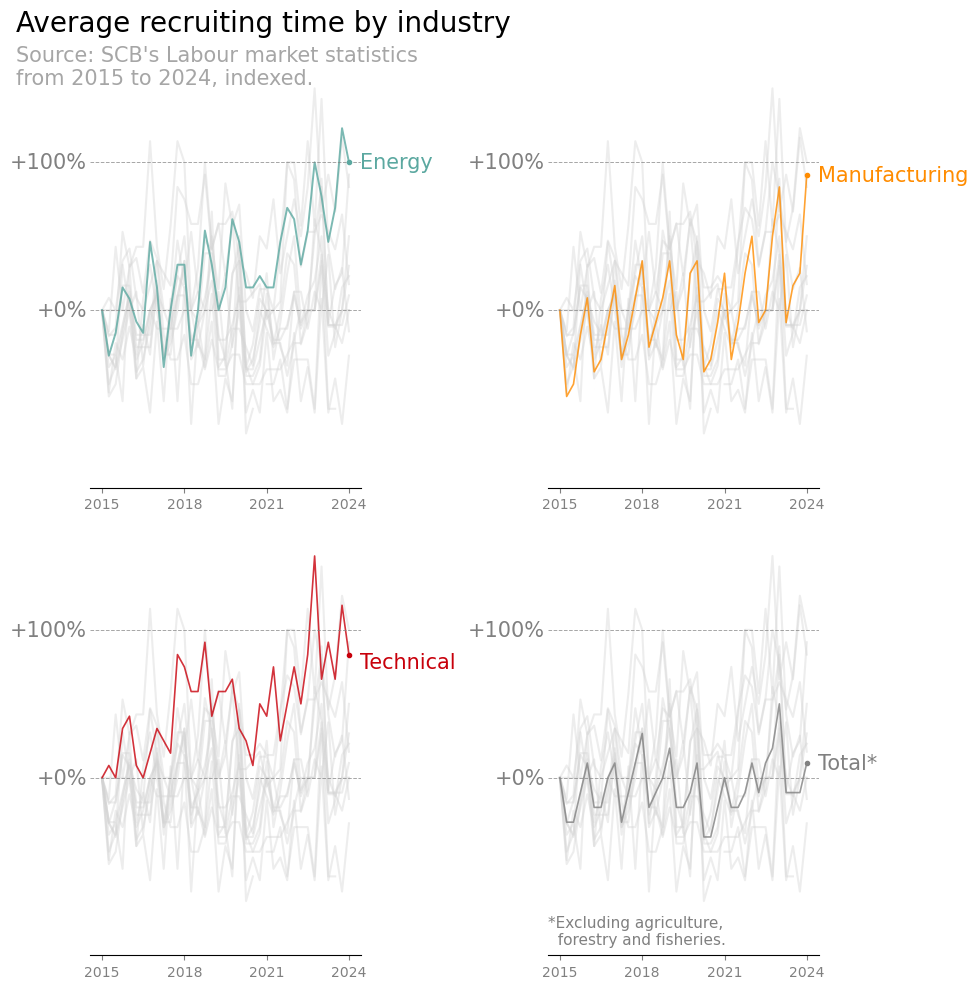

In [52]:
from matplotlib.transforms import blended_transform_factory

# Load the average recruitment time series and split into per-sector wide table
# vs. the all-sectors aggregate (A-S).
recruit_raw = pd.read_csv('mined_datasets/minned_average_recruitment_time_by_industry.csv', na_values=['..'])
recruit_raw['quarter_dt'] = pd.PeriodIndex(recruit_raw['quarter'].str.replace('K', 'Q'), freq='Q').to_timestamp()

wide = (recruit_raw
        .pivot(index='quarter_dt', columns='industry_code', values='average_recruitment_months')
        .sort_index())

# Indexed to the first available quarter (2015 Q2) per sector = 100
baseline = wide.iloc[0]
wide_idx = wide.divide(baseline) * 100

colors = {
    'M':   '#C8000B',  # muted red (matches the muted-teal saturation)
    'D+E': '#5BA8A0',  # muted teal
    'B+C': '#FF8C00',  # orange
    'A-S':'grey'
}

lw = {
    'M':   1.2,
    'D+E': 1.4,
    'B+C': 1.2,
    'A-S': 1.2,
}

sector_names = {
    'M': 'Technical',
    'D+E': 'Energy',
    'B+C': 'Manufacturing',
    'A-S': 'Total*'
}

# Endpoint label y-offsets (in points), keyed by industry_code. Tune per series
# when the endpoint label needs to clear another line; defaults to 0.
label_y_offset = {
    'M': -5,
    'D+E': 0,
    'B+C': 0,
}

# One subplot per highlighted sector, left -> right.
focus_order = ['D+E', 'B+C', 'M', 'A-S' ]

# Triennial x-ticks anchored at 2015 through 2024 (2015, 2018, 2021, 2024).
xticks = pd.to_datetime(['2015-01-01', '2018-01-01', '2021-01-01', '2024-01-01'])
ref_year = pd.Timestamp('2022-01-01')

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
axes = axes.flatten()
for ax, focus in zip(axes, focus_order):
    for col in wide_idx.columns:
        if col != focus:
            ax.plot(wide_idx.index, wide_idx[col], color='lightgrey', alpha=0.4)
    ax.plot(wide_idx.index, wide_idx[focus],
            color=colors[focus], linewidth=lw[focus], alpha=0.8)

    # Reference lines every 100 index points, % change vs baseline
    # (index 100 = 0%, 200 = +100%, etc.). Drawn + labelled on every subplot.
    y_min, y_max = ax.get_ylim()
    trans = blended_transform_factory(ax.transAxes, ax.transData)
    lo = 100
    hi = int(y_max // 100) * 100
    for v in range(max(0, lo), hi + 1, 100):
        if not (y_min <= v <= y_max):
            continue
        ax.axhline(v, color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
        ax.text(-0.01, v, f'{v - 100:+d}%', transform=trans,
                ha='right', va='center', fontsize=15, color='gray')



    # Endpoint marker + brief sector name on the focus series
    end_x = wide_idx.index[-1]
    y = wide_idx.iloc[-1][focus]
    y_off = label_y_offset.get(focus, 0)
    ax.plot(end_x, y, 'o', color=colors[focus], markersize=3)
    ax.annotate(sector_names[focus], xy=(end_x, y), xytext=(8, y_off),
                textcoords='offset points', va='center',
                color=colors[focus], fontweight='light', fontsize=15)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.set_xticks(xticks)

    ax.set_xticklabels([d.year for d in xticks])
    ax.tick_params(axis='x', labelsize=10, colors='gray')
    sns.despine(ax=ax, left=True)

axes[0].set_title('Average recruiting time by industry', pad=20, fontsize=20)
axes[0].text(-0.27, 0.932, "Source: SCB's Labour market statistics \nfrom 2015 to 2024, indexed.",
             transform=axes[0].transAxes,
             fontsize=15, color='gray', ha='left', va='bottom', alpha=0.7)
axes[3].text(0, 0.0182, "*Excluding agriculture, \n  forestry and fisheries.",
             transform=axes[3].transAxes,
             fontsize=11, color='gray', ha='left', va='bottom')
axes[0].title.set_position((-0.27, 1.0))
axes[0].title.set_ha('left')
axes[0].set_ylim(-20,270)
plt.tight_layout()

In [48]:
wide_idx

industry_code,A,A-S,B+C,D+E,F,G,H,I,J,K+L,M,N,P+Q,R+S
quarter_dt,,,,,,,,,,,,,,
2015-01-01,NaN,100.0,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.0,100.0,100.000000
2015-04-01,NaN,70.0,41.666667,69.230769,85.714286,44.444444,50.0,83.333333,82.352941,69.230769,108.333333,70.0,100.0,61.538462
2015-07-01,NaN,70.0,50.000000,84.615385,142.857143,77.777778,62.5,83.333333,88.235294,61.538462,100.000000,60.0,100.0,69.230769
2015-10-01,NaN,90.0,83.333333,115.384615,100.000000,66.666667,87.5,116.666667,152.941176,130.769231,133.333333,80.0,100.0,38.461538
2016-01-01,NaN,110.0,108.333333,107.692308,128.571429,88.888889,112.5,116.666667,129.411765,100.000000,141.666667,100.0,100.0,130.769231
2016-04-01,NaN,80.0,58.333333,92.307692,142.857143,66.666667,75.0,83.333333,135.294118,53.846154,108.333333,70.0,112.5,53.846154
2016-07-01,NaN,80.0,66.666667,84.615385,142.857143,77.777778,75.0,83.333333,111.764706,107.692308,100.000000,90.0,62.5,61.538462
2016-10-01,NaN,100.0,91.666667,146.153846,214.285714,100.000000,75.0,83.333333,147.058824,130.769231,116.666667,70.0,100.0,30.769231
2017-01-01,NaN,110.0,116.666667,115.384615,142.857143,111.111111,112.5,133.333333,135.294118,100.000000,133.333333,120.0,87.5,92.307692


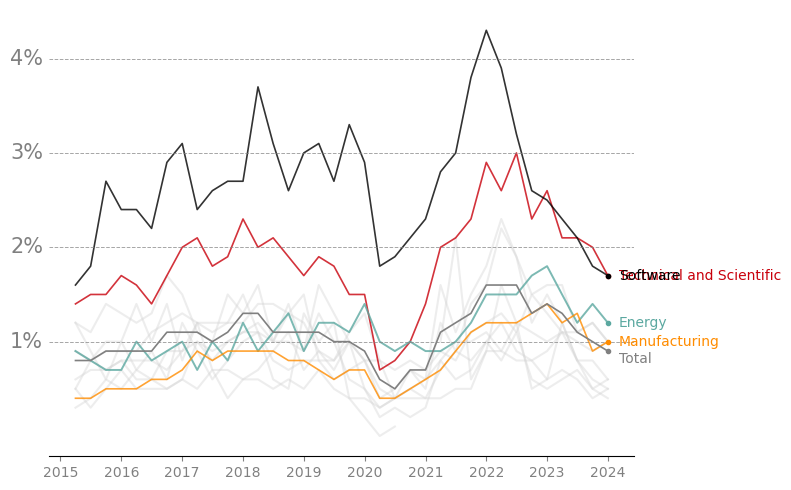

In [165]:
from matplotlib.transforms import blended_transform_factory

# Vacancy rates by industry, unindexed (absolute %)
vacancy_raw = pd.read_csv('mined_datasets/minned_recruitment_and_vacancy_rate_by_industry.csv', na_values=['..'])
vacancy_raw['quarter_dt'] = pd.PeriodIndex(vacancy_raw['quarter'].str.replace('K', 'Q'), freq='Q').to_timestamp()

vacancy_wide = (vacancy_raw[vacancy_raw['industry_code'] != 'A-S']
                .pivot(index='quarter_dt', columns='industry_code', values='vacancy_rate')
                .sort_index())

vacancy_total = (vacancy_raw[vacancy_raw['industry_code'] == 'A-S']
                 .set_index('quarter_dt')['vacancy_rate']
                 .sort_index())

highlight = ['M', 'D+E', 'B+C', 'J']
colors = {
    'M':   '#C8000B',
    'D+E': '#5BA8A0',
    'B+C': '#FF8C00',
    'J':'black',
    'A-S': 'gray',
}

lw = {
    'M':   1.2,
    'D+E': 1.4,
    'B+C': 1.2,
    'J':1.2,
    'A-S': 1.2,
}

sector_names = {
    'M': 'Technical and Scientific',
    'D+E': 'Energy',
    'B+C': 'Manufacturing',
    'J':'Software',
    'A-S': '\nTotal',
}

fig, ax = plt.subplots(figsize=(8, 5))

for col in vacancy_wide.columns:
    if col not in highlight:
        ax.plot(vacancy_wide.index, vacancy_wide[col], color='lightgrey', alpha=0.4)

for col in highlight:
    ax.plot(vacancy_wide.index, vacancy_wide[col], color=colors[col], linewidth=lw[col], alpha=0.8)

ax.plot(vacancy_total.index, vacancy_total.values, color=colors['A-S'], linewidth=lw['A-S'])

# Reference lines every 1 percentage point of vacancy rate
y_min, y_max = ax.get_ylim()
trans = blended_transform_factory(ax.transAxes, ax.transData)
for v in range(1, int(y_max) + 1):
    if not (y_min <= v <= y_max):
        continue
    ax.axhline(v, color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.text(-0.01, v, f'{v}%', transform=trans,
            ha='right', va='center', fontsize=15, color='gray')

# Endpoint marker + brief sector name (use last non-null observation per series)
end_x = vacancy_wide.index[-1]
endpoint_y = {col: vacancy_wide[col].dropna().iloc[-1] for col in highlight}
endpoint_y['A-S'] = vacancy_total.dropna().iloc[-1]

for col, y in endpoint_y.items():
    ax.plot(end_x, y, 'o', color=colors[col], markersize=3)
    ax.annotate(sector_names[col], xy=(end_x, y), xytext=(8, 0),
                textcoords='offset points', va='center',
                color=colors[col], fontweight='light', fontsize=10)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=10, colors='gray')
sns.despine(ax=ax, left=True)
plt.tight_layout()

In [352]:
vacancy_wide

industry_code,A,B+C,D+E,F,G,H,I,J,K+L,M,N,P+Q,R+S
quarter_dt,,,,,,,,,,,,,
2015-04-01,NaN,0.4,0.9,0.9,0.6,0.3,1.2,1.6,0.9,1.4,1.2,0.5,0.5
2015-07-01,NaN,0.4,0.8,0.8,0.7,0.4,0.9,1.8,0.8,1.5,1.1,0.3,0.8
2015-10-01,NaN,0.5,0.7,1.0,0.7,0.6,0.6,2.7,0.9,1.5,1.4,0.5,0.7
2016-01-01,NaN,0.5,0.7,1.0,0.8,0.5,1.0,2.4,0.9,1.7,1.3,0.7,0.8
2016-04-01,NaN,0.5,1.0,1.4,0.6,0.7,0.7,2.4,0.9,1.6,1.2,0.5,0.8
2016-07-01,NaN,0.6,0.8,1.0,0.6,0.6,0.9,2.2,1.1,1.4,1.3,0.5,0.8
2016-10-01,NaN,0.6,0.9,1.4,0.9,0.5,0.6,2.9,1.2,1.7,1.7,0.5,0.7
2017-01-01,NaN,0.7,1.0,0.8,0.9,0.6,1.2,3.1,1.3,2.0,1.5,0.6,0.9
2017-04-01,0.8,0.9,0.7,1.2,1.0,1.0,0.9,2.4,1.2,2.1,1.1,0.5,1.2


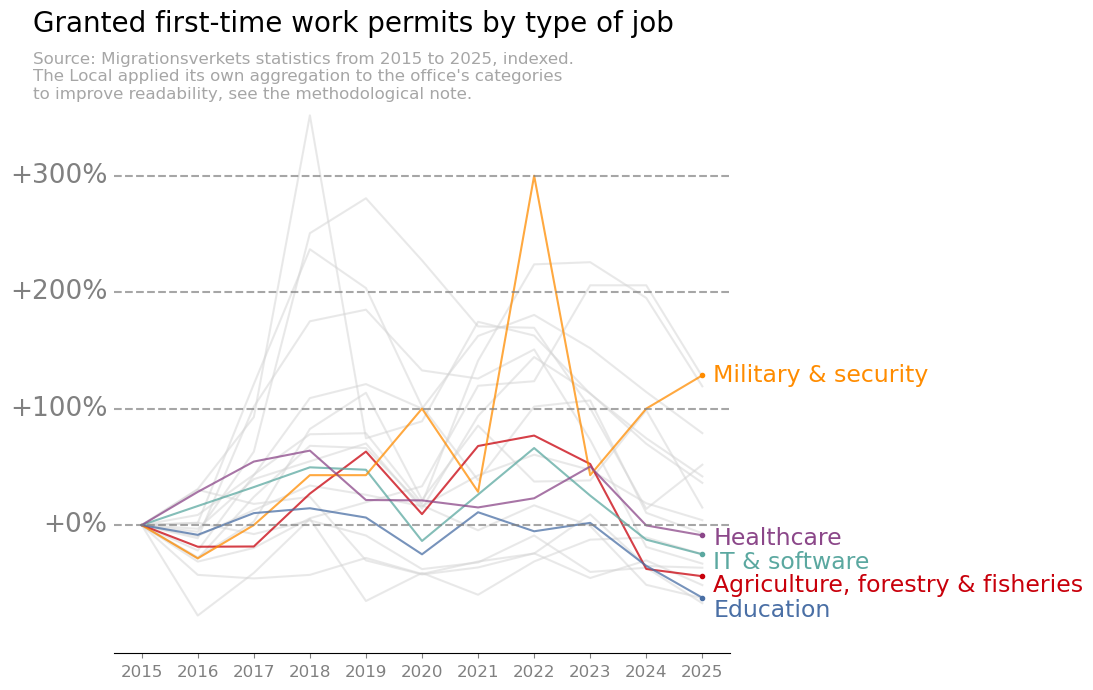

In [193]:
# First-time work permits granted by occupation category, indexed to 2021 = 100
permits_raw = pd.read_csv('mined_datasets/minned_work_permits_granted_by_category.csv')
permits_first = permits_raw[permits_raw['permit_type'] == 'first-time'].copy()
permits_first.loc[permits_first['occupation_category'].isin(['Care & nursing aides', 'Doctors & dentists', 'Nurses & allied health']), "occupation_category"] = 'Healthcare'

permits_wide = (permits_first
                .pivot_table(index='year',
                             columns='occupation_category',
                             values='number_granted_applications',
                             aggfunc='sum')
                .sort_index())

# Drop categories that are zero/NaN at baseline (can't index against zero)
permits_baseline = permits_wide.iloc[0]
permits_wide = permits_wide[permits_baseline[permits_baseline > 0].index]
permits_idx = permits_wide.divide(permits_wide.iloc[0]) * 100

highlight = [
    'Agriculture, forestry & fisheries',
    'IT & software',
    # 'Hospitality & food service',
    # 'Cleaning & building maintenance',
    'Military & security',
    'Education',
    'Healthcare',
]

palette = ['#C8000B', '#5BA8A0', '#FF8C00', '#4A6FA5', '#8B4789', '#2E8B57']
colors = {col: palette[i] for i, col in enumerate(highlight)}

lw = {col: 1.5 for col in highlight}

# Endpoint label y-offsets (in points). Hospitality, Education, Agriculture and
# Cleaning sit in a tight band near idx 30-39 in 2025; offsets here are tuned to
# give roughly equal vertical spacing between their labels.
label_y_offset = {
    'IT & software':-6,
    'Healthcare':-2,
    'Education': -9,
    'Agriculture, forestry & fisheries': -7,
    'Cleaning & building maintenance': 1,
}

fig, ax = plt.subplots(figsize=(11, 7))

for col in permits_idx.columns:
    if col not in highlight:
        ax.plot(permits_idx.index, permits_idx[col], color='lightgrey', alpha=0.5)

for col in highlight:
    ax.plot(permits_idx.index, permits_idx[col],
            color=colors[col], linewidth=lw[col], alpha=0.75)

# Extend the y-axis well below 0 so the lowest line (Cleaning) and its label
# sit clearly above the bottom spine, with the negative offsets above.
ax.set_ylim(bottom=-10)

# Reference lines every 100 index points, labelled with % change vs baseline
y_min, y_max = ax.get_ylim()
trans = blended_transform_factory(ax.transAxes, ax.transData)
lo = 100
hi = int(y_max // 100) * 100
for v in range(max(0, lo), hi + 1, 100):
    if not (y_min <= v <= y_max):
        continue
    ax.axhline(v, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(-0.01, v, f'{v - 100:+d}%', transform=trans,
            ha='right', va='center', fontsize=19, color='gray')

# Endpoint marker + category name
end_x = permits_idx.index[-1]
for col in highlight:
    y = permits_idx.iloc[-1][col]
    y_off = label_y_offset.get(col, 0)
    ax.plot(end_x, y, 'o', color=colors[col], markersize=3)
    ax.annotate(col, xy=(end_x, y), xytext=(8, y_off),
                textcoords='offset points', va='center',
                color=colors[col], fontweight='light', fontsize=17)

ax.set_xticks(permits_idx.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=12, colors='gray', pad=5)
ax.set_title('Granted first-time work permits by type of job', pad=42, fontsize=20)
ax.text(-0.13, 0.98, "Source: Migrationsverkets statistics from 2015 to 2025, indexed.\n"
                     "The Local applied its own aggregation "
                     "to the office's categories \nto improve readability, see the methodological note.",
             transform=ax.transAxes,
             fontsize=12, color='gray', ha='left', va='bottom', alpha=0.7)
ax.title.set_position((-0.13, 1.0))
ax.title.set_ha('left')
sns.despine(ax=ax, left=True)
plt.tight_layout()

In [287]:
permits_idx

occupation_category,"Agriculture, forestry & fisheries","Arts, media & culture","Business, finance & legal",Cleaning & building maintenance,Construction trades,Education,Engineering professionals,General management,Healthcare,Hospitality & food service,IT & software,Manufacturing & factory work,Military & security,Natural sciences (research),Personal services & sports,Religion & social work,"Sales, retail & marketing",Transport & logistics,Unknown / other,Vehicle & equipment mechanics
year,,,,,,,,,,,,,,,,,,,,
2015,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2016,81.408451,130.909091,96.836983,88.709677,94.242424,91.634981,108.695652,57.251908,128.484848,71.242775,116.370749,72.330097,71.428571,68.627451,101.754386,130.303030,90.632319,78.195489,22.321429,102.032520
2017,81.619718,192.727273,139.416058,201.612903,163.030303,110.266160,143.300799,54.198473,154.545455,124.205202,132.621125,102.912621,100.000000,80.392157,221.052632,118.181818,112.880562,142.857143,58.928571,92.276423
2018,127.018779,451.818182,154.744526,275.000000,350.606061,114.448669,177.994676,57.251908,163.939394,168.063584,149.593741,182.524272,142.857143,105.882353,336.842105,124.242424,133.957845,209.022556,105.357143,104.065041
2019,163.122066,174.545455,170.072993,284.946237,380.606061,106.463878,178.881988,71.755725,121.515152,166.112717,147.517304,213.592233,142.857143,119.607843,303.508772,69.696970,125.995316,221.052632,34.821429,91.056911
2020,109.413146,189.090909,114.111922,232.795699,327.272727,74.904943,118.633540,58.015267,121.212121,116.979769,86.367740,121.844660,200.000000,133.333333,201.754386,57.575758,116.159251,200.000000,58.928571,62.195122
2021,167.910798,274.545455,193.673966,225.806452,270.606061,111.026616,241.171251,68.702290,115.151515,95.520231,126.211255,185.436893,128.571429,219.607843,138.596491,63.636364,142.622951,262.406015,40.178571,67.886179
2022,176.854460,262.727273,244.282238,250.806452,269.393939,94.676806,323.868678,75.572519,123.030303,116.979769,166.145050,137.378641,400.000000,223.529412,201.754386,75.757576,160.421546,280.451128,68.750000,91.056911
2023,152.464789,212.727273,213.138686,173.118280,200.303030,101.901141,325.732032,109.160305,150.303030,99.349711,125.308456,138.349515,142.857143,305.882353,207.017544,54.545455,147.306792,251.879699,87.500000,59.756098


In [299]:
permits_wide

occupation_category,"Agriculture, forestry & fisheries","Arts, media & culture","Business, finance & legal",Cleaning & building maintenance,Construction trades,Education,Engineering professionals,General management,Healthcare,Hospitality & food service,IT & software,Manufacturing & factory work,Military & security,Natural sciences (research),Personal services & sports,Religion & social work,"Sales, retail & marketing",Transport & logistics,Unknown / other,Vehicle & equipment mechanics
year,,,,,,,,,,,,,,,,,,,,
2015,4260,110,411,372,330,263,1127,131,330,1384,3323,206,7,51,57,33,427,133,112,246
2016,3468,144,398,330,311,241,1225,75,424,986,3867,149,5,35,58,43,387,104,25,251
2017,3477,212,573,750,538,290,1615,71,510,1719,4407,212,7,41,126,39,482,190,66,227
2018,5411,497,636,1023,1157,301,2006,75,541,2326,4971,376,10,54,192,41,572,278,118,256
2019,6949,192,699,1060,1256,280,2016,94,401,2299,4902,440,10,61,173,23,538,294,39,224
2020,4661,208,469,866,1080,197,1337,76,400,1619,2870,251,14,68,115,19,496,266,66,153
2021,7153,302,796,840,893,292,2718,90,380,1322,4194,382,9,112,79,21,609,349,45,167
2022,7534,289,1004,933,889,249,3650,99,406,1619,5521,283,28,114,115,25,685,373,77,224
2023,6495,234,876,644,661,268,3671,143,496,1375,4164,285,10,156,118,18,629,335,98,147


In [288]:
37/100

0.37